# Detect output

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


## Use celldetect notebook to create files!

In [2]:
jupyter nbconvert --to script ../celldetect/celldetect.ipynb

[NbConvertApp] Converting notebook ../celldetect/celldetect.ipynb to script
[NbConvertApp] Writing 2882 bytes to celldetect.sh


In [3]:
bash celldetect.sh
##REGRESSION_TEST: bash $CIAOTEST_TESTS/threads/celldetect.MAIN

CIAO configuration is complete... 
The CIAO setup for this window has changed from
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3
To:
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3

  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  486.6 kb/s
  oif      fits       25 Kb  ####################          < 1 s  571.2 kb/s
  vv       pdf        46 Kb  ####################          < 1 s  1283.8 kb/s
  cntr_img fits      129 Kb  ####################          < 1 s  10160.3 kb/s
  cntr_img jpg       575 Kb  ####################          < 1 s  15929.1 kb/s
  evt2     fits       10 Mb  ####################          < 1 s  38111.3 kb/s
  full_img fits       76 Kb  ####################          < 1 s  3635.1 kb/s
  full_img jpg       

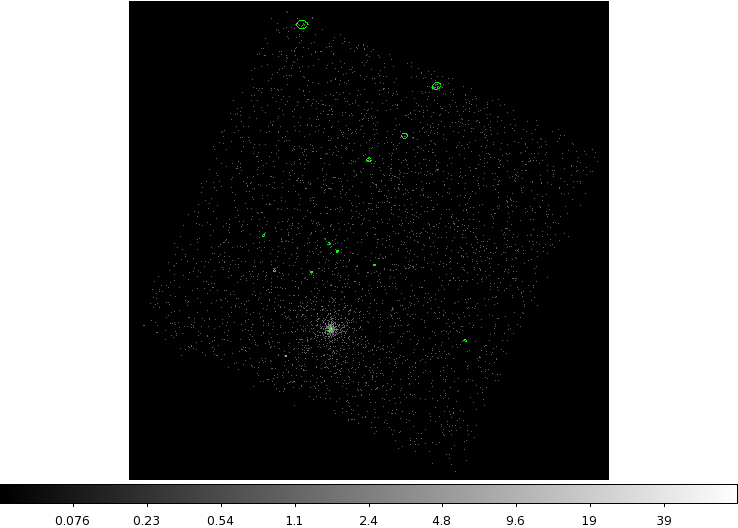

In [9]:
ds9 s3_broad_thresh.img -log -region s3_src.fits -zoom to fit -saveimage png ds9_1.png -quit
display < ds9_1.png

## Examing source list

In [10]:
dmlist s3_src.fits blocks

 
--------------------------------------------------------------------------------
Dataset: s3_src.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SRCLIST                        Table        31 cols x 15       rows


In [11]:
dmlist "s3_src.fits[cols RA,DEC,POS]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    RA                   DEC                  POS(X,Y)
 
     1       212.8639501188        52.1921273978 (     3961.7571428571,     4035.0714285714)
     2       212.8474548928        52.2255111480 (     4035.7917808219,     4279.3205479452)
     3       212.8360726227        52.2021137798 (     4086.8032786885,     4108.1147540984)
     4       212.8353651758        52.2027847341 (     4089.9759036145,     4113.0240963855)
     5       212.8349227409        52.2031706722           (     4091.960,     4115.8480)
     6       212.8067722124        52.2280881209 (     4218.1290322581,     4298.1935483871)
     7       212.8783563224        52.2399625097 (     3897.3529411765,     4385.1176470588)
     8       212.8712813825        52.2258301626       (     3929.0,     4281.6923076923)
     9 

## Manipulate


In [14]:
dmcopy "s3_src.fits[#row=1:11,13:15]" s3_1gone_src.fits cl+
dmlist s3_1gone_src.fits blocks

 
--------------------------------------------------------------------------------
Dataset: s3_1gone_src.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SRCLIST                        Table        31 cols x 14       rows


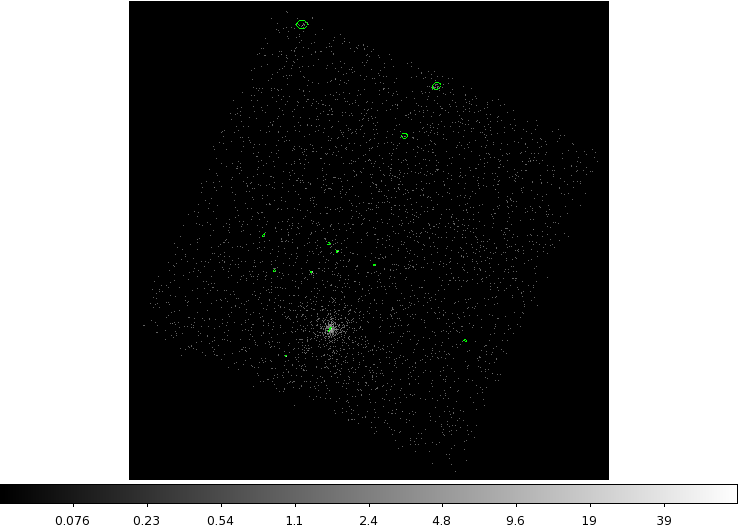

In [15]:
ds9 s3_broad_thresh.img -log -region s3_1gone_src.fits -zoom to fit -saveimage png ds9_2.png -quit
display < ds9_2.png

In [16]:
dmcopy "s3_src.fits[#row=1:7,9:11,13,15]" s3_3gone_src.fits clob+

dmlist s3_3gone_src.fits blocks


 
--------------------------------------------------------------------------------
Dataset: s3_3gone_src.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SRCLIST                        Table        31 cols x 12       rows


In [17]:
dmlist s3_3gone_src.fits"[cols ra,dec,net_counts]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    RA                   DEC                  NET_COUNTS
 
     1       212.8639501188        52.1921273978               63.250
     2       212.8474548928        52.2255111480                320.0
     3       212.8360726227        52.2021137798             33.43750
     4       212.8353651758        52.2027847341             87.81250
     5       212.8349227409        52.2031706722              67.6250
     6       212.8067722124        52.2280881209             29.31250
     7       212.8783563224        52.2399625097        31.4285717010
     8       212.8360692107        52.2365737442        20.4285717010
     9       212.8309806527        52.2335386574       125.5714263916
    10       212.7481005259        52.1982204514        51.1428565979
    11       212.7873357718        52.27921

## Sort

In [18]:
dmlist "s3_src.fits[cols net_counts]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1               63.250
     2                320.0
     3             33.43750
     4             87.81250
     5              67.6250
     6             29.31250
     7        31.4285717010
     8        23.4285717010
     9        20.4285717010
    10       125.5714263916
    11        51.1428565979
    12        25.3977279663
    13                 32.0
    14        76.7916641235
    15        54.7449989319


In [19]:
dmsort s3_src.fits s3_sorted_src.fits keys=net_counts copyall=yes cl+

dmlist "s3_sorted_src.fits[cols net_counts]" data
 

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1        20.4285717010
     2        23.4285717010
     3        25.3977279663
     4             29.31250
     5        31.4285717010
     6                 32.0
     7             33.43750
     8        51.1428565979
     9        54.7449989319
    10               63.250
    11              67.6250
    12        76.7916641235
    13             87.81250
    14       125.5714263916
    15                320.0


In [20]:
dmsort s3_src.fits s3_descend_src.fits keys=-net_counts

dmlist "s3_descend_src.fits[cols net_counts]" data
 

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1                320.0
     2       125.5714263916
     3             87.81250
     4        76.7916641235
     5              67.6250
     6               63.250
     7        54.7449989319
     8        51.1428565979
     9             33.43750
    10                 32.0
    11        31.4285717010
    12             29.31250
    13        25.3977279663
    14        23.4285717010
    15        20.4285717010


## Filtering 

In [21]:
dmcopy "s3_src.fits[net_counts=40:]" s3_40cts_src.fits cl+
dmlist "s3_40cts_src.fits[cols net_counts]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1               63.250
     2                320.0
     3             87.81250
     4              67.6250
     5       125.5714263916
     6        51.1428565979
     7        76.7916641235
     8        54.7449989319


In [22]:
dmcopy "s3_src.fits[net_counts=25:80]" s3_25-80cts_src.fits cl+
dmlist "s3_25-80cts_src.fits[cols net_counts]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1               63.250
     2             33.43750
     3              67.6250
     4             29.31250
     5        31.4285717010
     6        51.1428565979
     7        25.3977279663
     8                 32.0
     9        76.7916641235
    10        54.7449989319


## Convert coords

### ds9


In [23]:
echo skip

skip


### precess

In [24]:
dmlist s3_src.fits"[cols ra,dec]" data,clean > decimal.txt

prop_precess f j2000/deg t j2000/hms : decimal.txt : hms.txt

Opened input file decimal.txt
Opened output file hms.txt


In [25]:
cat hms.txt

RA,Dec J2000.0                          RA,Dec J2000.0
212.863950    52.192127                 14 11 27.35 +52 11 31.66
212.847455    52.225511                 14 11 23.39 +52 13 31.84
212.836073    52.202114                 14 11 20.66 +52 12 07.61
212.835365    52.202785                 14 11 20.49 +52 12 10.03
212.834923    52.203171                 14 11 20.38 +52 12 11.41
212.806772    52.228088                 14 11 13.63 +52 13 41.12
212.878356    52.239963                 14 11 30.81 +52 14 23.87
212.871281    52.225830                 14 11 29.11 +52 13 32.99
212.836069    52.236574                 14 11 20.66 +52 14 11.67
212.830981    52.233539                 14 11 19.44 +52 14 00.74
212.748101    52.198220                 14 10 59.54 +52 11 53.59
212.810193    52.269778                 14 11 14.45 +52 16 11.20
212.787336    52.279212                 14 11 08.96 +52 16 45.16
212.766588    52.298921                 14 11 03.98 +52 17 56.11
212.853594    52.323235            

## Using srclist in Analysis

### Single Spectra

In [27]:
evt="578/primary/acisf00578N003_evt2.fits"

punlearn dmextract

dmextract "${evt}[sky=region(s3_src.fits[#row=2])][bin pi=::1]" \
      spectrum.fits cl+


In [28]:
cat << EOM > p1.py
make_figure("spectrum.fits[cols channel,counts]")
limits(X_AXIS,0,100)
print_window("chips_1.png","export.clobber=True")
quit()
EOM

chips -b p1.py
display < chips_1.png

Xlib:  extension "GLX" missing on display ":4.0".
chips ERROR: There are currently no windows to operate on

bash: chips_1.png: No such file or directory


### Multiple, type II

In [29]:
dmextract "${evt}[sky=region(s3_src.fits[component=igrid(1:15:1)])][bin pi=::1]" \
      multi_spectra_phaII.fits op=pha2 clob+


In [30]:
dmlist multi_spectra_phaII.fits blocks

 
--------------------------------------------------------------------------------
Dataset: multi_spectra_phaII.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SPECTRUM                       Table         7 cols x 15       rows
Block    3: GTI7                           Table         2 cols x 1        rows
Block    4: GTI5                           Table         2 cols x 1        rows
Block    5: GTI2                           Table         2 cols x 7        rows
Block    6: GTI3                           Table         2 cols x 7        rows
Block    7: GTI8                           Table         2 cols x 4        rows
Block    8: GTI6                           Table         2 cols x 4        rows


### Co-add spectra

In [31]:
dmcopy "s3_src.fits[#row=1:2,6:]" s3_nocore_src.fits cl+

In [32]:
dmextract "${evt}[sky=region(s3_nocore_src.fits)][bin pi=::1]" \
      spectrum_faint.fits cl+

In [34]:
cat << EOM > p2.py
make_figure("spectrum_faint.fits[cols channel,counts]","symbol.style=none")
limits(X_AXIS,0,100)
print_window("chips_2.png","export.clobber=True")
quit()
EOM

chips -b p2.py
display < chips_2.png

Xlib:  extension "GLX" missing on display ":4.0".
chips ERROR: There are currently no windows to operate on

bash: chips_2.png: No such file or directory


## Remove pt srcs

In [35]:
dmcopy "s3_src.fits[#row=1:2,6:15]" s3_holes_src.fits cl+

In [36]:
dmcopy "${evt}[exclude sky=region(s3_holes_src.fits)]" s3_holes_evt2.fits cl+

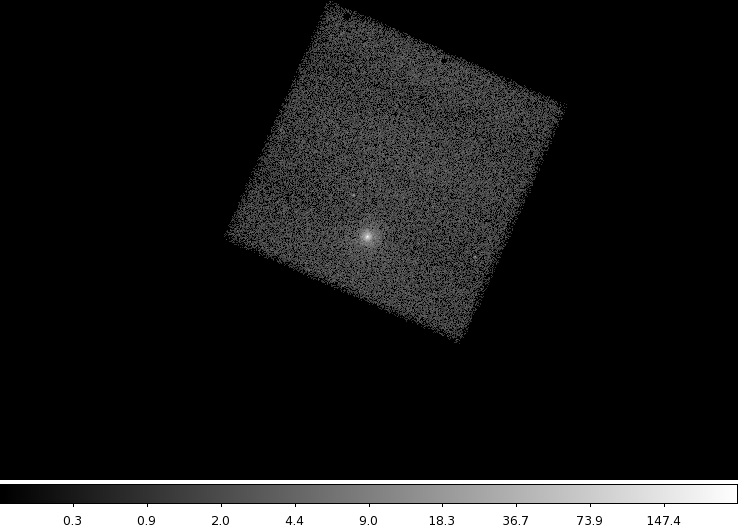

In [40]:
ds9 s3_holes_evt2.fits"[events,ccd_id=7]" -log -bin factor 4 -saveimage png ds9_3.png -quit
display < ds9_3.png

## As catalog


In [42]:
wget -q http://cxc.cfa.harvard.edu/ciao/threads/detect_output/src2tsv

In [43]:
python src2tsv s3_expmap_src.fits s3_src.tsv

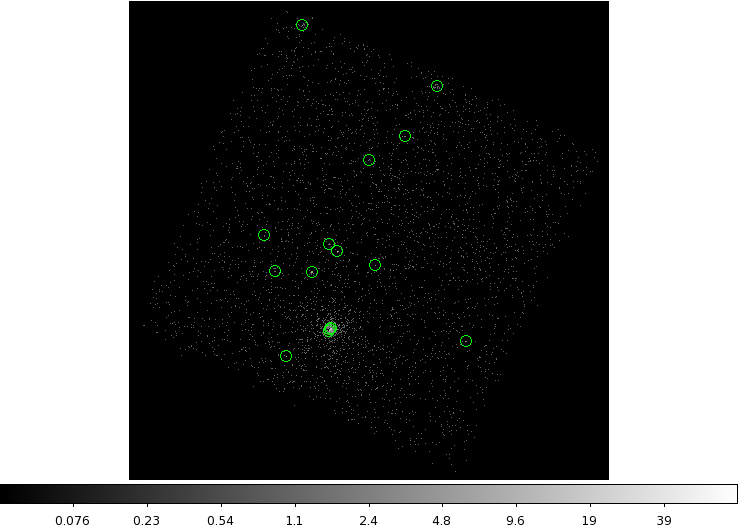

In [46]:
ds9 s3_broad_thresh.img -log -zoom to fit -catalog import tsv s3_src.tsv -saveimage png ds9_4.png -quit
display < ds9_4.png

### Cross match with 2MASS
    It's too hard to do the cross match stuff via notebook.  But one could it via xpa commands if you really wanted too.